Data Loaded 

Before Balancing:
label
5     1998026
1     1887175
4      987063
3      974359
11     704503
9      540498
7      514724
10     462480
6      230856
17     230339
15     106603
8       52881
2       36039
13      20666
0       17791
12       6877
16       3207
14        926
Name: count, dtype: int64


/tmp/ipykernel_57/460419058.py:50: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: x.sample(



After Balancing:
label
0     5000
1     5000
2     5000
3     5000
4     5000
5     5000
6     5000
7     5000
8     5000
9     5000
10    5000
11    5000
12    5000
13    5000
15    5000
17    5000
16    3207
14     926
Name: count, dtype: int64

Top Features:
['Weight', 'ack_flag_number', 'Protocol_Type', 'ack_count', 'TCP', 'Number', 'Tot_sum', 'fin_count', 'syn_flag_number', 'AVG', 'Max', 'Min', 'syn_count', 'rst_count', 'Tot_size', 'Magnitue', 'Header_Length', 'Rate', 'Srate', 'IAT']

Training Models...


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
2026-06-06 20:20:21.086464: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


Epoch 1/20
693/693 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.4443 - loss: 1.4848 - val_accuracy: 0.6089 - val_loss: 0.7068
Epoch 2/20
693/693 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.5924 - loss: 0.7449 - val_accuracy: 0.6292 - val_loss: 0.6789
Epoch 3/20
693/693 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.5996 - loss: 0.7227 - val_accuracy: 0.6226 - val_loss: 0.6715
Epoch 4/20
693/693 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.6143 - loss: 0.6984 - val_accuracy: 0.6154 - val_loss: 0.6658
Epoch 5/20
693/693 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.6193 - loss: 0.6922 - val_accuracy: 0.6288 - val_loss: 0.6565
Epoch 6/20
693/693 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.6175 - loss: 0.6873 - val_accuracy: 0.6362 - val_loss: 0.6510
Epoch 7/20
693/693 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.6197 - loss: 0.6794 - val_accuracy: 0.6341 - val_loss: 0.6522
Epoch 8/20
693/693 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.6255 - loss: 0.6708 - val_accuracy: 0.

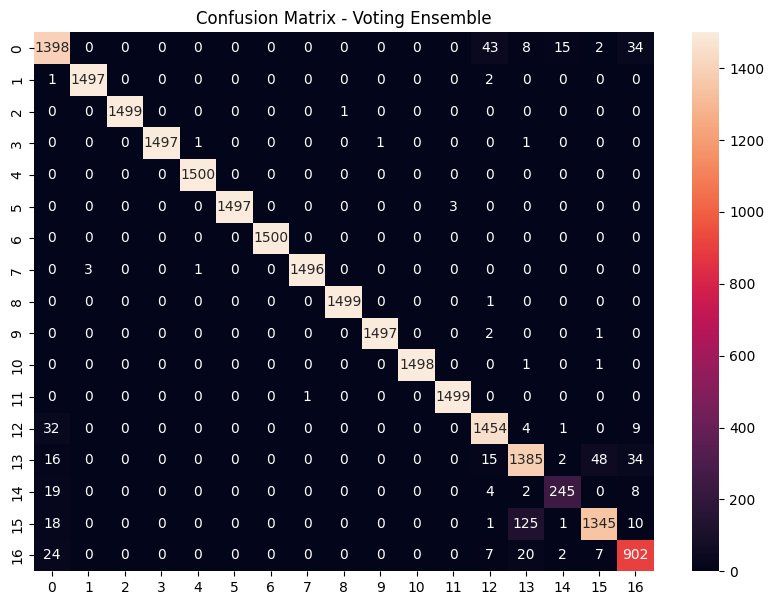


 FINAL ZERO-DAY RESULT
Total Samples: 5000
Detected Attacks: 4722
Detection Rate: 94.44%


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score, GridSearchCV
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier, VotingClassifier, IsolationForest

# ===== Deep Learning =====
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix


train_df = pd.read_csv('/kaggle/input/datasets/shahdsameh123/shahd-s/train_iomt.csv', low_memory=False)
test_df  = pd.read_csv('/kaggle/input/datasets/shahdsameh123/shahd-s/test_iomt.csv', low_memory=False)

df = pd.concat([train_df, test_df], axis=0)

print("Data Loaded ")


df = df.dropna()
df.columns = df.columns.str.replace(' ', '_')


le = LabelEncoder()

for col in df.select_dtypes(include='object').columns:
    df[col] = le.fit_transform(df[col])

target_col = 'label'


print("\nBefore Balancing:")
print(df[target_col].value_counts())

n_samples = 5000

df_balanced = (
    df.groupby(target_col, group_keys=False)
      .apply(lambda x: x.sample(
          n=min(len(x), n_samples),
          random_state=42
      ))
      .reset_index(drop=True)
)

print("\nAfter Balancing:")
print(df_balanced[target_col].value_counts())


zero_day_label = 17

df_known = df_balanced[df_balanced[target_col] != zero_day_label]
df_zero  = df_balanced[df_balanced[target_col] == zero_day_label]


X = df_known.drop(columns=[target_col])
y = df_known[target_col]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.3,
    random_state=42,
    stratify=y
)


rf_selector = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf_selector.fit(X_train, y_train)

importances = rf_selector.feature_importances_

indices = np.argsort(importances)[-20:]

top_features = X.columns[indices]

X_train = X_train[top_features]
X_test  = X_test[top_features]

X_zero = df_zero[top_features]

print("\nTop Features:")
print(list(top_features))


scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)
X_zero_scaled  = scaler.transform(X_zero)



# ===== Random Forest =====
rf = RandomForestClassifier(
    n_estimators=300,
    max_depth=25,
    random_state=42
)

# ===== XGBoost =====
xgb = XGBClassifier(
    n_estimators=400,
    learning_rate=0.03,
    max_depth=8,
    subsample=0.9,
    colsample_bytree=0.9,
    eval_metric='mlogloss',
    random_state=42
)

# ===== LightGBM =====
lgbm = LGBMClassifier(
    n_estimators=400,
    learning_rate=0.03,
    num_leaves=64,
    random_state=42,
    verbose=-1
)

# =====================================
# 10. Deep Learning Model
# =====================================
num_classes = len(np.unique(y_train))

dl_model = Sequential([
    
    Dense(128, activation='relu', input_shape=(X_train_scaled.shape[1],)),
    Dropout(0.3),

    Dense(64, activation='relu'),
    Dropout(0.3),

    Dense(32, activation='relu'),

    Dense(num_classes, activation='softmax')
])

dl_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)


print("\nTraining Models...")

rf.fit(X_train, y_train)

xgb.fit(X_train, y_train)

lgbm.fit(X_train, y_train)

dl_model.fit(
    X_train_scaled,
    y_train,
    validation_split=0.2,
    epochs=20,
    batch_size=64,
    callbacks=[early_stop],
    verbose=1
)


rf_pred = rf.predict(X_test)

xgb_pred = xgb.predict(X_test)

lgbm_pred = lgbm.predict(X_test)

dl_pred = np.argmax(
    dl_model.predict(X_test_scaled),
    axis=1
)


vote = VotingClassifier(
    estimators=[
        ('rf', rf),
        ('xgb', xgb),
        ('lgbm', lgbm)
    ],
    voting='soft'
)

vote.fit(X_train, y_train)

vote_pred = vote.predict(X_test)


results = {
    "RF": accuracy_score(y_test, rf_pred),
    "XGB": accuracy_score(y_test, xgb_pred),
    "LGBM": accuracy_score(y_test, lgbm_pred),
    "Deep Learning": accuracy_score(y_test, dl_pred),
    "Voting Ensemble": accuracy_score(y_test, vote_pred)
}

print("\n========== RESULTS ==========")

for k, v in results.items():
    print(f"{k}: {v:.4f}")

best_model_name = max(results, key=results.get)

print("\nBest Model:", best_model_name)


if best_model_name == "RF":
    final_pred = rf_pred
    final_model = rf

elif best_model_name == "XGB":
    final_pred = xgb_pred
    final_model = xgb

elif best_model_name == "LGBM":
    final_pred = lgbm_pred
    final_model = lgbm

elif best_model_name == "Deep Learning":
    final_pred = dl_pred
    final_model = dl_model

else:
    final_pred = vote_pred
    final_model = vote


print("\nClassification Report:")
print(classification_report(y_test, final_pred))

cm = confusion_matrix(y_test, final_pred)

plt.figure(figsize=(10,7))
sns.heatmap(cm, annot=True, fmt='d')
plt.title(f"Confusion Matrix - {best_model_name}")
plt.show()



# ===== Isolation Forest =====
iso = IsolationForest(
    contamination=0.20,
    n_estimators=300,
    random_state=42
)

iso.fit(X_train_scaled)

# ===== Predictions =====
vote_zero_preds = vote.predict(X_zero)

iso_preds = iso.predict(X_zero_scaled)

# ===== Hybrid Decision =====
final_zero_preds = []

for v, i in zip(vote_zero_preds, iso_preds):

    if i == -1:
        final_zero_preds.append(1)

    else:
        if v == 0:
            final_zero_preds.append(0)
        else:
            final_zero_preds.append(1)

final_zero_preds = np.array(final_zero_preds)

detected = final_zero_preds.sum()

total = len(final_zero_preds)

detection_rate = (detected / total) * 100


print("\n" + "="*40)
print(" FINAL ZERO-DAY RESULT")
print("="*40)

print(f"Total Samples: {total}")

print(f"Detected Attacks: {detected}")

print(f"Detection Rate: {detection_rate:.2f}%")


cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

scores = cross_val_score(
    rf,
    X[top_features],
    y,
    cv=cv
)

print("\nCross Validation Mean:", scores.mean())


joblib.dump(vote, "FINAL_HYBRID_MODEL.pkl")

print("\nModel Saved ✅")


sample = X_test.iloc[0:1]

pred = vote.predict(sample)

print("\nSample Prediction:", pred)

print("Actual:", y_test.iloc[0])